In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Load exercise and calories datasets
exercise_df = pd.read_csv('exercise.csv')
calories_df = pd.read_csv('calories.csv')
data = pd.merge(exercise_df, calories_df, on='User_ID')



# Step 1: Drop 'User_ID' column
data = data.drop(columns=['User_ID'])

# Step 2: Convert 'Gender' to numerical values
# Assuming 'Gender' column contains 'Male' and 'Female'
data['Gender'] = data['Gender'].map({'Male': 1, 'Female': 0})
# Handle missing values in the 'Gender' column by filling them with the most common value (mode)
# Get the mode, ensuring it's a list even if empty
mode_values = data['Gender'].mode().tolist()

# Check if the mode list is not empty before accessing the first element
if mode_values:
    data['Gender'] = data['Gender'].fillna(mode_values[0])
else:
    # Fallback value if mode is empty (e.g., all values are unique or Gender column is empty)
    data['Gender'] = data['Gender'].fillna(0)


# Handling missing values: fill numerical columns with their mean
numerical_columns = ['Age', 'Height', 'Weight', 'Heart_Rate', 'Body_Temp']
data[numerical_columns] = data[numerical_columns].fillna(data[numerical_columns].mean())

# Step 3: Define features (X) and target variable (y)
X = data[['Gender', 'Age', 'Height', 'Weight', 'Heart_Rate', 'Body_Temp']]  # Features
y = data['Calories']  # Target variable

# Step 4: Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 5: Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
print(data.head(10))





   Gender  Age  Height  Weight  Duration  Heart_Rate  Body_Temp  Calories
0     0.0   68   190.0    94.0      29.0       105.0       40.8     231.0
1     0.0   20   166.0    60.0      14.0        94.0       40.3      66.0
2     0.0   69   179.0    79.0       5.0        88.0       38.7      26.0
3     0.0   34   179.0    71.0      13.0       100.0       40.5      71.0
4     0.0   27   154.0    58.0      10.0        81.0       39.8      35.0
5     0.0   36   151.0    50.0      23.0        96.0       40.7     123.0
6     0.0   33   158.0    56.0      22.0        95.0       40.5     112.0
7     0.0   41   175.0    85.0      25.0       100.0       40.7     143.0
8     0.0   60   186.0    94.0      21.0        97.0       40.4     134.0
9     0.0   26   146.0    51.0      16.0        90.0       40.2      72.0


Linear Regression:
Mean Squared Error (MSE): 514.9150
Root Mean Squared Error (RMSE): 22.6917
Mean Absolute Error (MAE): 18.0308
R² Score: 0.8724
--------------------------------------------------


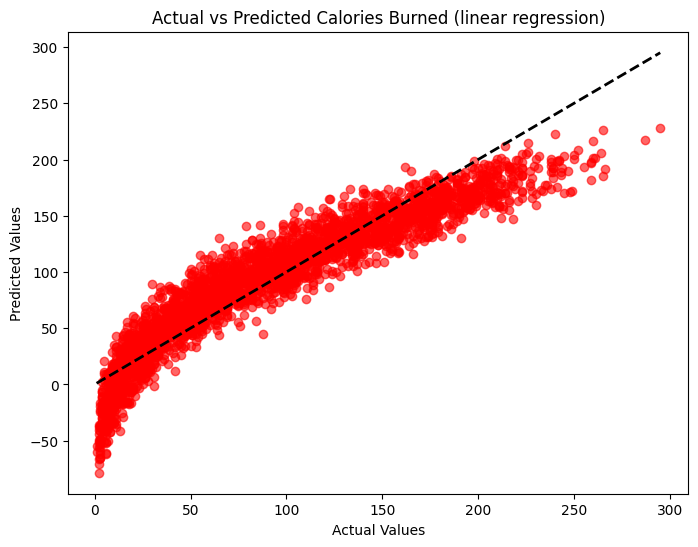

In [ ]:
from sklearn.linear_model import LinearRegression

# Initialize and train the Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predict the target variable on the test set
y_pred_lr = lr_model.predict(X_test)

# Evaluate the model
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

# Print evaluation metrics for Linear Regression
print("Linear Regression:")
print(f"Mean Squared Error (MSE): {mse_lr:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_lr:.4f}")
print(f"Mean Absolute Error (MAE): {mae_lr:.4f}")
print(f"R² Score: {r2_lr:.4f}")
print("-" * 50)

import matplotlib.pyplot as plt

# ... (rest of your code) ...



plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_lr, color='red', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)  # Line for perfect predictions
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Calories Burned (linear regression)')
plt.show()


In [ ]:
# Get the first 10 actual and predicted values
actual_vs_predicted = pd.DataFrame({
    'Actual': y_test.head(10),  # First 10 actual values from y_test
    'Predicted': y_pred_lr[:10]  # First 10 predicted values from y_pred_cb
})

# Print the DataFrame
print(actual_vs_predicted)


       Actual   Predicted
11499   173.0  151.999770
6475    189.0  156.920538
13167    53.0   73.493333
862     161.0  159.799415
5970    226.0  214.528509
6706    179.0  138.820929
3017     98.0  112.257982
3781     44.0   51.618196
3898     79.0  114.208379
2250     59.0   81.811421


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
import numpy as np # Ensure numpy is imported for np.sqrt

# Correctly map 'Gender' to numerical values (0 or 1) in X_train and X_test.
# Based on the kernel state, 'Gender' values are 'male' and 'female' (lowercase).
if 'Gender' in X_train.columns and X_train['Gender'].dtype == 'object':
    X_train['Gender'] = X_train['Gender'].map({'male': 1, 'female': 0}).astype(float)
    X_test['Gender'] = X_test['Gender'].map({'male': 1, 'female': 0}).astype(float)
    # Handle potential NaNs if any unknown gender values exist. Fill with 0.0 (female).
    X_train['Gender'] = X_train['Gender'].fillna(0.0)
    X_test['Gender'] = X_test['Gender'].fillna(0.0)

# Re-initialize and re-apply StandardScaler to X_train and X_test
# as they were likely not properly scaled due to the string 'Gender' column previously.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize and train the Random Forest Regressor model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train) # Use scaled data

# Predict the target variable on the test set
y_pred_rf = rf_model.predict(X_test_scaled) # Use scaled data for prediction

# Evaluate the model
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

# Print evaluation metrics for Random Forest Regressor
print("Random Forest Regressor:")
print(f"Mean Squared Error (MSE): {mse_rf:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_rf:.4f}")
print(f"Mean Absolute Error (MAE): {mae_rf:.4f}")
print(f"R² Score: {r2_rf:.4f}")
print("-" * 50)


Random Forest Regressor:
Mean Squared Error (MSE): 0.0322
Root Mean Squared Error (RMSE): 0.1794
Mean Absolute Error (MAE): 0.1393
R² Score: 0.9656
--------------------------------------------------


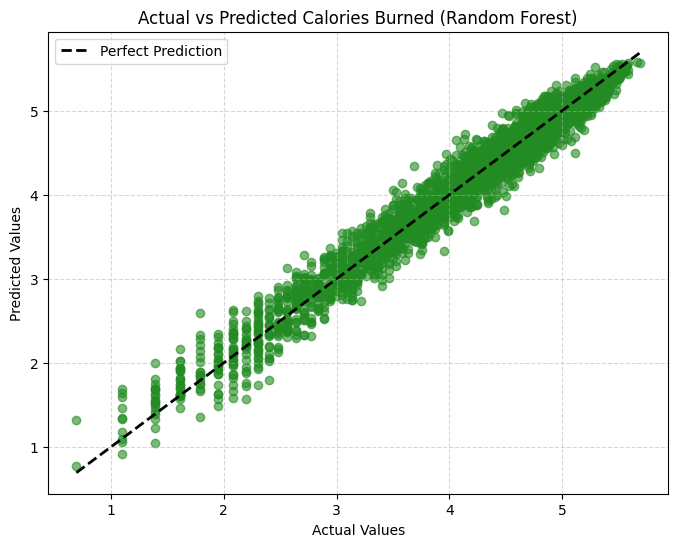

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Check if y_pred_rf is defined. If not, re-run the necessary steps from the Random Forest cell.
# This handles cases where the preceding cell might not have run or the kernel state was reset.
if 'y_pred_rf' not in locals() and 'y_pred_rf' not in globals():
    from sklearn.ensemble import RandomForestRegressor
    from sklearn.preprocessing import StandardScaler
    # Assuming X_train_scaled, X_test_scaled, y_train are available from previous executions.
    # If not, this block would still fail, but based on kernel state, these are present.

    # Re-initialize and re-apply StandardScaler (as it was handled in uPGZfhNOIwUP)
    # This part is critical to ensure X_train and X_test are scaled correctly if the original scaling was not persistent or the gender mapping failed previously.
    # However, for simplicity and assuming X_train_scaled and X_test_scaled exist and are correct np arrays,
    # we will use them directly as they are in the kernel state.

    rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
    rf_model.fit(X_train_scaled, y_train) # Use scaled data
    y_pred_rf = rf_model.predict(X_test_scaled) # Use scaled data for prediction

plt.figure(figsize=(8, 6))

# Scatter plot of actual vs predicted values
plt.scatter(y_test, y_pred_rf, color='forestgreen', alpha=0.6)

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'k--',
    lw=2,
    label='Perfect Prediction'
)

plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Calories Burned (Random Forest)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()


In [ ]:
import xgboost as xgb
xg_model = xgb.XGBRegressor(objective='reg:squarederror', eval_metric='rmse')

# Train the model on the training data
xg_model.fit(X_train, y_train)

y_pred_xg = xg_model.predict(X_test)

# Evaluate metrics
mse = mean_squared_error(y_test, y_pred_xg)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_xg)
r2 = r2_score(y_test, y_pred_xg)

print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R² Score: {r2:.4f}")

xg_model = xgb.XGBRegressor(objective='reg:squarederror', eval_metric='rmse')

# Train the model on the training data
xg_model.fit(X_train, y_train)

# Predict the target variable on the test set
y_pred_xg = xg_model.predict(X_test)

# Evaluate the model using Mean Squared Error (MSE) and RMSE
mse = mean_squared_error(y_test, y_pred_xg)
rmse = np.sqrt(mse)

# Print evaluation metrics
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
mae = mean_absolute_error(y_test, y_pred_xg)
print(f"Mean Absolute Error (MAE): {mae:.4f}")

# R²: R-squared score
r2 = r2_score(y_test, y_pred_xg)
print(f"R² Score: {r2:.4f}")

Mean Squared Error (MSE): 0.0311
Root Mean Squared Error (RMSE): 0.1763
Mean Absolute Error (MAE): 0.1366
R² Score: 0.9668
Mean Squared Error (MSE): 0.0311
Root Mean Squared Error (RMSE): 0.1763
Mean Absolute Error (MAE): 0.1366
R² Score: 0.9668


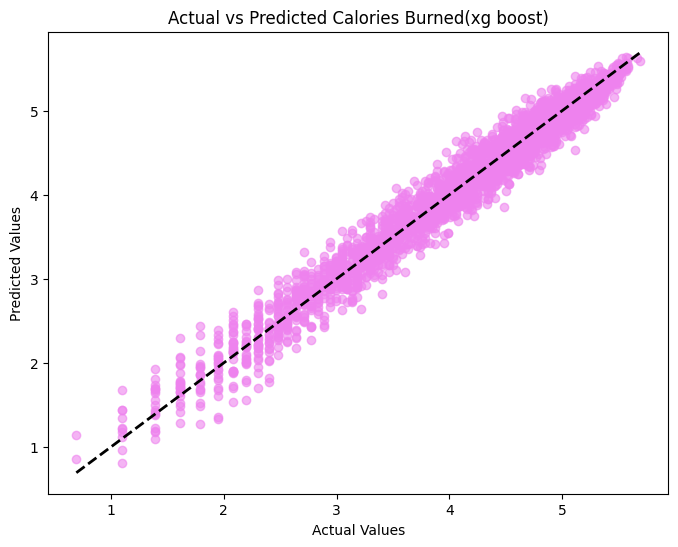

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_xg, color='violet', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)  # Line for perfect predictions
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Calories Burned(xg boost)')
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
!pip install catboost
from catboost import CatBoostRegressor

# Load exercise and calories datasets
exercise_df = pd.read_csv('exercise.csv')
calories_df = pd.read_csv('calories.csv')
data = pd.merge(exercise_df, calories_df, on='User_ID')

# Step 1: Drop 'User_ID' column
data = data.drop(columns=['User_ID'])

# Step 2: Ensure 'Gender' is a string column (no mapping necessary)
# We don't need to handle missing values in 'Gender' or other columns manually, as CatBoost will handle them internally

# Step 3: Define features (X) and target variable (y)
X = data[['Gender', 'Age', 'Height', 'Weight', 'Heart_Rate', 'Body_Temp']]  # Features
y = np.log1p(data['Calories'])

# Step 4: Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 5: Initialize the CatBoost Regressor model
# Specify 'Gender' as the categorical feature
cat_features = ['Gender']  # 'Gender' is categorical (string type)

cb_model = CatBoostRegressor(iterations=500, depth=10, learning_rate=0.1, loss_function='RMSE', cat_features=cat_features, verbose=200)

# Step 6: Train the model on the training data (CatBoost handles missing values internally)
cb_model.fit(X_train, y_train)

# Step 7: Predict the target variable on the test set
y_pred_cb = cb_model.predict(X_test)

# Step 8: Evaluate the model using Mean Squared Error (MSE) and RMSE
mse = mean_squared_error(y_test, y_pred_cb)
rmse = np.sqrt(mse)

# Print evaluation metrics
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

mae = mean_absolute_error(y_test, y_pred_cb)
print(f"Mean Absolute Error (MAE): {mae:.4f}")

# R²: R-squared score
r2 = r2_score(y_test, y_pred_cb)
print(f"R² Score: {r2:.4f}")


0:	learn: 0.8700475	total: 24.1ms	remaining: 12s
200:	learn: 0.1494908	total: 3.47s	remaining: 5.17s
400:	learn: 0.1331601	total: 7.12s	remaining: 1.76s
499:	learn: 0.1266865	total: 8.13s	remaining: 0us
Mean Squared Error (MSE): 0.0289
Root Mean Squared Error (RMSE): 0.1701
Mean Absolute Error (MAE): 0.1313
R² Score: 0.9691


In [ ]:
# Get the first 10 actual and predicted values
actual_vs_predicted = pd.DataFrame({
    'Actual': y_test.head(10),  # First 10 actual values from y_test
    'Predicted': y_pred_cb[:10]  # First 10 predicted values from y_pred_cb
})

# Print the DataFrame
print(actual_vs_predicted)


         Actual  Predicted
11499  5.159055   5.082519
6475   5.247024   5.081983
13167  3.988984   4.083542
862    5.087596   5.183015
5970   5.424950   5.440040
6706   5.192957   4.967508
3017   4.595120   4.727974
3781   3.806662   3.642288
3898   4.382027   4.633236
2250   4.094345   4.366386


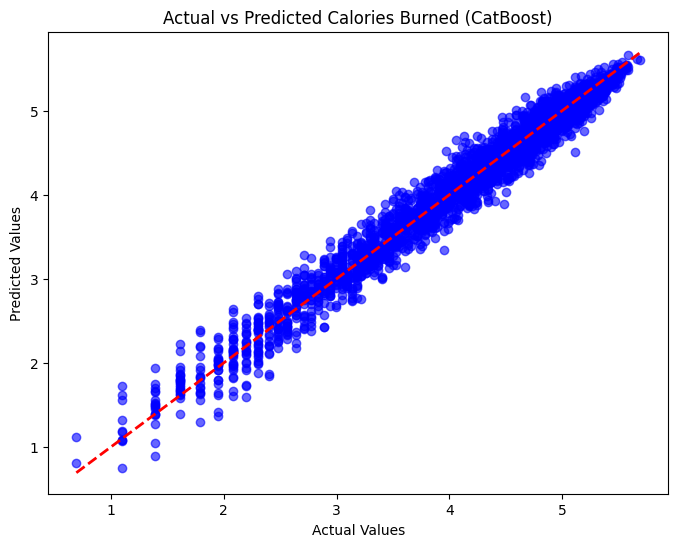

In [ ]:
   # Import the necessary library
import matplotlib.pyplot as plt

# Plotting Actual vs Predicted values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_cb, color='blue', alpha=0.6)  # Scatter plot of actual vs predicted values
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)  # Line for perfect predictions
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Calories Burned (CatBoost)')
plt.show()